# A Supervisory Portfolio Governance Framework
## Master Quantitative Replication Notebook

This notebook executes the complete Dependency-Aware Supervisory Portfolio Governance Framework. It is structured in three acts:
1. **Methodological Baseline (U1):** Validates the statistical reality of the US equity market, constructs the Composite Instability Index ($I_t$), and evaluates the framework against traditional Mean-Variance optimization.
2. **Cross-Universe Generalization (U2-U5):** Applies the locked framework to European ETFs, Asia-Pacific ETFs, US Sectors, and a Multi-Asset macro portfolio to prove structural robustness.
3. **Synthesis:** Generates all publication-ready tables and high-resolution figures.

In [1]:
# ================================================================
# CELL 1 — MASTER SETUP & UNIVERSAL FUNCTION LIBRARY
# Locks all parameters and definitions for the entire paper
# ================================================================

import numpy as np
import pandas as pd
import yfinance as yf
import cvxpy as cp
from sklearn.covariance import LedoitWolf
from scipy.stats import ttest_rel, ttest_ind, jarque_bera, wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
os.makedirs("universe_results", exist_ok=True)

# ── 1. LOCKED GOVERNANCE PARAMETERS ─────────────────────────────
TRAIN_WINDOW = 504       # 2-year estimation window
TEST_WINDOW  = 63        # ~3-month holding period
INST_WINDOW  = 60        # 60-day rolling instability window
THETA_H      = 1.0       # Regime switching threshold (Z-score)
LAMBDA_0     = 3.0       # Base risk aversion
TC_BPS       = 10        # Transaction costs (basis points)
TRAIN_CUTOFF = pd.Timestamp("2019-12-31")

MODELS = ["static", "equal", "shrunk", "regime", "minvar"]
COLORS = {"static": "#1f77b4", "equal": "#2ca02c", "shrunk": "#d62728", 
          "regime": "#9467bd", "minvar": "#8c6d31"}
LABELS = {"static": "Static MV (Baseline)", "equal": "Equal Weight (1/N)",
          "shrunk": "MV + JS+LW Shrinkage", "regime": "Regime Switch (Proposed)", 
          "minvar": "Min-Variance (LW)"}

STRESS_EVENTS = {
    "EU Debt Crisis": ("2011-07-01", "2012-06-30"),
    "China Crash":    ("2015-06-01", "2016-02-28"),
    "COVID Shock":    ("2020-02-15", "2020-06-30"),
    "Fed Rate Hikes": ("2022-01-01", "2022-12-31")
}

# ── 2. UNIVERSE DEFINITIONS ─────────────────────────────────────
UNIVERSES = {
    "U1": ["AAPL", "MSFT", "GOOGL", "AMZN", "JNJ", "PFE", "UNH", "JPM", "BAC", "GS", 
           "MS", "PG", "KO", "PEP", "XOM", "CVX", "COP", "BA", "CAT"],
    "U2": ["VGK", "EZU", "IEV", "EWG", "EWQ", "EWI", "EWP", "EWL", "EWN", "EWD"],
    "U3": ["VPL", "EWJ", "EWA", "EWY", "EWT", "EWS", "EWM", "INDA", "EIDO", "EPHE"],
    "U4": ["XLK", "XLV", "XLF", "XLY", "XLP", "XLE", "XLI", "XLU", "XLB"],
    "U5": ["SPY", "TLT", "IEF", "LQD", "GLD", "DBC", "VNQ", "USO", "UUP", "HYG"]
}

# ── 3. CORE MATHEMATICAL FUNCTIONS ──────────────────────────────
def fetch_universe(u_key, start="2010-01-01", end="2024-12-31"):
    """Fetches adjusted close prices and calculates log returns."""
    tickers = UNIVERSES[u_key]
    data = yf.download(tickers, start=start, end=end, auto_adjust=False, progress=False)
    prices = data.xs("Adj Close", axis=1, level=0) if isinstance(data.columns, pd.MultiIndex) else data["Adj Close"]
    prices = prices.dropna(how="all").ffill().bfill()
    returns = np.log(prices / prices.shift(1)).dropna()
    return returns[[t for t in tickers if t in returns.columns]]

def shrink_mu_james_stein(mu, n_obs):
    """James-Stein Shrinkage for Expected Returns."""
    p, mu_bar = len(mu), mu.mean()
    diff, norm_sq = mu - mu_bar, ((mu - mu_bar)**2).sum()
    if norm_sq == 0: return mu.copy()
    sf = float(np.clip(1 - (p - 2) / (n_obs * norm_sq), 0, 1))
    return mu_bar + sf * diff

def shrink_cov_lw(train_data):
    """Ledoit-Wolf Shrinkage for Covariance."""
    lw = LedoitWolf().fit(train_data.values)
    return pd.DataFrame(lw.covariance_, index=train_data.columns, columns=train_data.columns)

def mv_opt(mu, Sigma, lam):
    """Standard Mean-Variance Optimizer with SCS/OSQP fallbacks."""
    n = len(mu)
    w = cp.Variable(n)
    prob = cp.Problem(cp.Maximize(mu.values @ w - (lam / 2) * cp.quad_form(w, Sigma.values)), [cp.sum(w) == 1, w >= 0])
    for solver in [cp.SCS, cp.OSQP]:
        try:
            prob.solve(solver=solver, verbose=False)
            if w.value is not None:
                wt = np.clip(w.value, 0, None)
                return pd.Series(wt / wt.sum(), index=mu.index)
        except: pass
    return pd.Series(np.ones(n) / n, index=mu.index)

def minvar_opt(Sigma):
    """Minimum Variance Optimizer."""
    n = len(Sigma)
    w = cp.Variable(n)
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, Sigma.values)), [cp.sum(w) == 1, w >= 0])
    for solver in [cp.SCS, cp.OSQP]:
        try:
            prob.solve(solver=solver, verbose=False)
            if w.value is not None:
                wt = np.clip(w.value, 0, None)
                return pd.Series(wt / wt.sum(), index=Sigma.index)
        except: pass
    return pd.Series(np.ones(n) / n, index=Sigma.index)

print("✅ Master Setup Complete. All mathematical functions and universes loaded into memory.")

✅ Master Setup Complete. All mathematical functions and universes loaded into memory.


## Statistical Reality (Universe 1)
Traditional mean-variance optimization assumes asset returns are normally distributed. This cell proves via the Jarque-Bera test and visual Q-Q distributions that financial returns possess extreme "fat tails" (kurtosis), justifying the necessity of shrinkage estimators.

Fetching U1 Baseline Data...

TABLE 1: U1 SUMMARY STATISTICS
| Ticker   |   Ann. Return |   Ann. Vol |   Skewness |   Kurtosis |   JB p-val | Normal?   |
|:---------|--------------:|-----------:|-----------:|-----------:|-----------:|:----------|
| AAPL     |     0.244955  |   0.278765 | -0.235329  |    5.45315 |          0 | NO        |
| AMZN     |     0.233705  |   0.326573 |  0.0122529 |    5.98062 |          0 | NO        |
| UNH      |     0.200632  |   0.254286 | -0.357836  |   10.8701  |          0 | NO        |
| MSFT     |     0.193958  |   0.255786 | -0.210491  |    8.02414 |          0 | NO        |
| GOOGL    |     0.167319  |   0.272647 |  0.114749  |    7.45393 |          0 | NO        |
| CAT      |     0.147543  |   0.290898 | -0.295775  |    4.1446  |          0 | NO        |
| JPM      |     0.140639  |   0.277435 | -0.0760755 |    9.68028 |          0 | NO        |
| MS       |     0.115036  |   0.338725 | -0.0264412 |    8.58637 |          0 | NO        |
| GS     

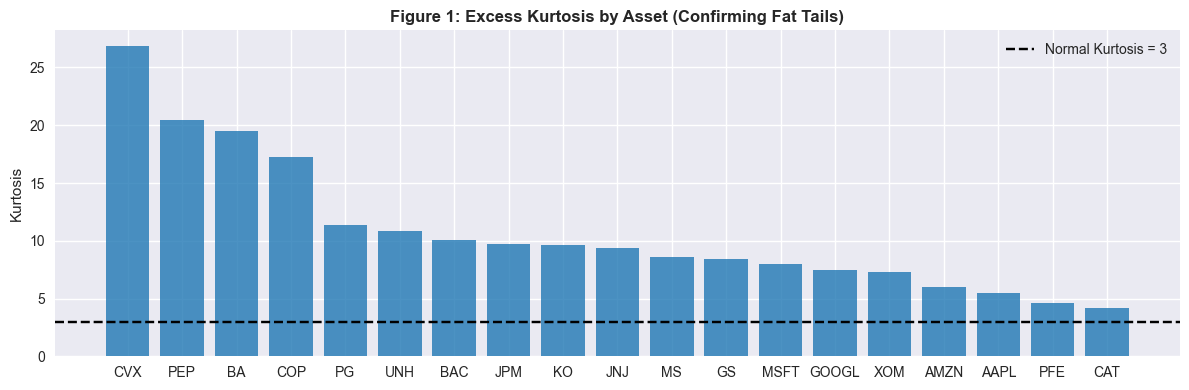

In [4]:
# ================================================================
# CELL 2 — U1 STATISTICAL REALITY & DISTRIBUTIONS (Table 1, Fig 1)
# ================================================================

print("Fetching U1 Baseline Data...")
ret_u1 = fetch_universe("U1")

# ── Summary Statistics & Normality (Table 1) ────────────────────
stats_u1 = pd.DataFrame({
    "Ann. Return": ret_u1.mean() * 252,
    "Ann. Vol":    ret_u1.std()  * np.sqrt(252),
    "Skewness":    ret_u1.skew(),
    "Kurtosis":    ret_u1.kurtosis()
})

jb_stat, jb_pval = zip(*[jarque_bera(ret_u1[t].dropna()) for t in ret_u1.columns])
stats_u1["JB p-val"] = jb_pval
stats_u1["Normal?"] = ["YES" if p > 0.05 else "NO" for p in jb_pval]

print("\nTABLE 1: U1 SUMMARY STATISTICS")
print(stats_u1.sort_values("Ann. Return", ascending=False).to_markdown())
print(f"\nNormality Rejected in: {(stats_u1['Normal?'] == 'NO').sum()}/{len(ret_u1.columns)} assets.")

# ── Figure 1: Kurtosis Bar Chart ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
kurt_vals = stats_u1["Kurtosis"].sort_values(ascending=False)
bars = ax.bar(kurt_vals.index, kurt_vals.values, color=COLORS["static"], alpha=0.8)
ax.axhline(3, color="black", linestyle="--", label="Normal Kurtosis = 3")
ax.set_title("Figure 1: Excess Kurtosis by Asset (Confirming Fat Tails)", fontweight="bold")
ax.set_ylabel("Kurtosis")
ax.legend()
plt.tight_layout()
plt.savefig("universe_results/U1_Fig1_Kurtosis.png", dpi=150)
plt.show()

## Correlation Dynamics & Composite Instability Index ($I_t$)
This section demonstrates the breakdown of diversification during stress periods (correlation goes to 1) and formally constructs the Composite Instability Index ($I_t$). The index synthesizes three distinct dimensions of structural risk: rolling volatility ($\sigma_t$), mean pairwise correlation ($\rho_t$), and covariance matrix drift ($\delta_t$) calculated via the Frobenius norm.

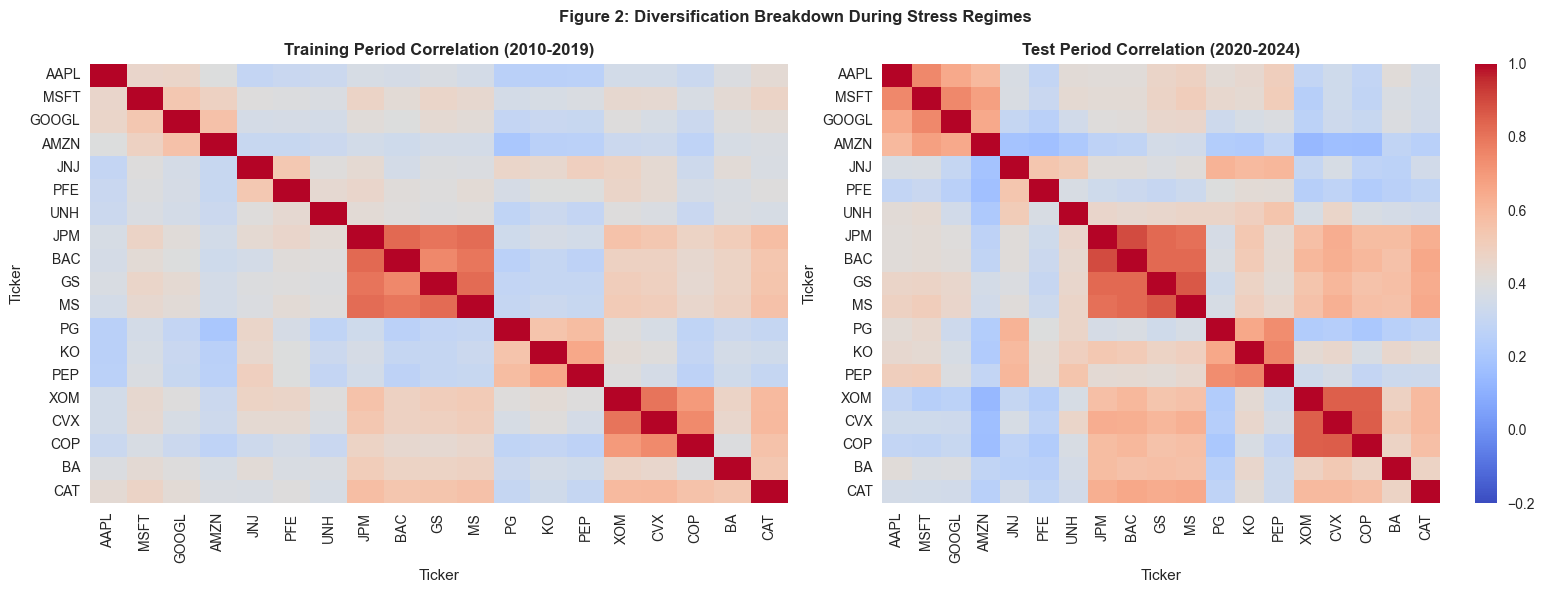


Building Composite Instability Index (takes ~30 sec)...


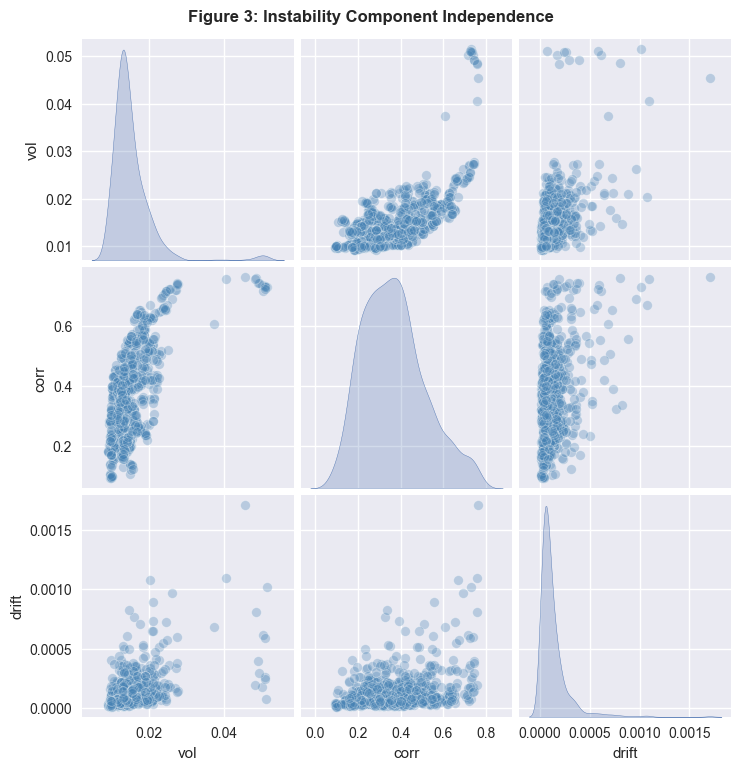

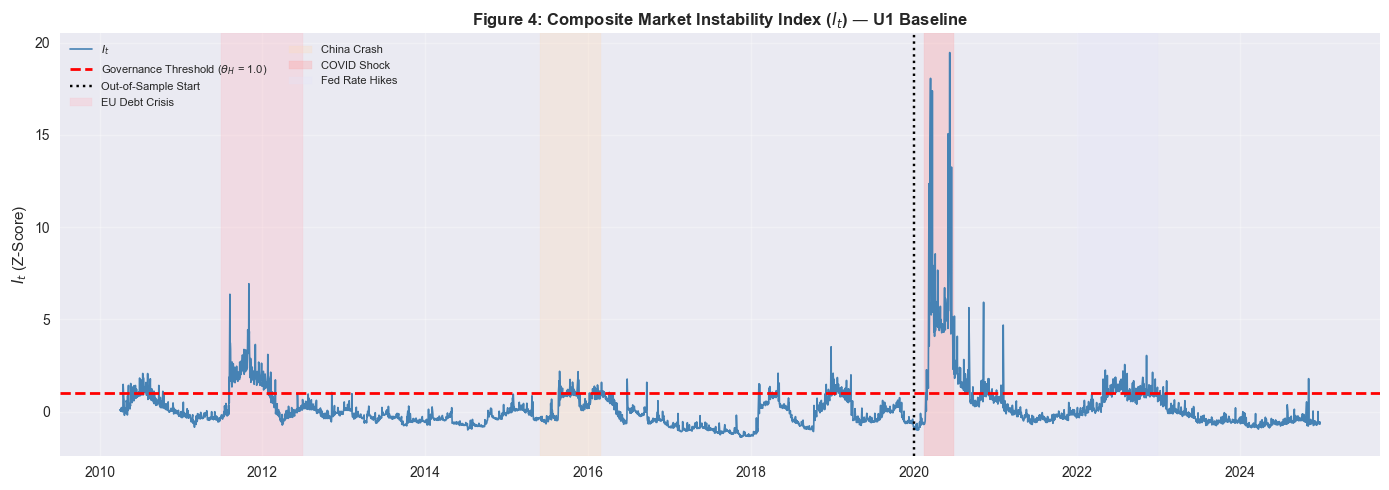

✅ Correlation and Instability construction complete!


In [5]:
# ================================================================
# CELL 3 — U1 CORRELATION DYNAMICS & INSTABILITY (Fig 2, Fig 3, Fig 4)
# ================================================================

# ── Figure 2: Train vs Test Correlation Breakdown ──────────────
train_u1 = ret_u1[ret_u1.index <= TRAIN_CUTOFF]
test_u1  = ret_u1[ret_u1.index >= "2020-01-01"]

corr_train = train_u1.corr()
corr_test  = test_u1.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_train, cmap="coolwarm", vmin=-0.2, vmax=1.0, ax=axes[0], cbar=False)
axes[0].set_title("Training Period Correlation (2010-2019)", fontweight="bold")
sns.heatmap(corr_test, cmap="coolwarm", vmin=-0.2, vmax=1.0, ax=axes[1])
axes[1].set_title("Test Period Correlation (2020-2024)", fontweight="bold")
fig.suptitle("Figure 2: Diversification Breakdown During Stress Regimes", fontweight="bold")
plt.tight_layout()
plt.savefig("universe_results/U1_Fig2_CorrelationBreakdown.png", dpi=150)
plt.show()

# ── Build Instability Index (I_t) ───────────────────────────────
print("\nBuilding Composite Instability Index (takes ~30 sec)...")

vol_vals, corr_vals, drift_vals, dates = [], [], [], []
prev_cov = None

for i in range(INST_WINDOW, len(ret_u1)):
    w_ret = ret_u1.iloc[i - INST_WINDOW : i]
    dates.append(w_ret.index[-1])
    
    # 1. Cross-sectional Volatility
    vol_vals.append(w_ret.std().mean())
    
    # 2. Mean Pairwise Correlation
    c_mat = w_ret.corr().values
    corr_vals.append(c_mat[np.triu_indices_from(c_mat, k=1)].mean())
    
    # 3. Covariance Drift (Frobenius Norm)
    cov_mat = w_ret.cov().values
    drift = np.linalg.norm(cov_mat - prev_cov, ord="fro") if prev_cov is not None else np.nan
    drift_vals.append(drift)
    prev_cov = cov_mat

# Assemble Raw Components
inst_df = pd.DataFrame({"vol": vol_vals, "corr": corr_vals, "drift": drift_vals}, index=dates).dropna()

# ── Figure 3: Component Independence ────────────────────────────
fig = sns.pairplot(inst_df.sample(min(800, len(inst_df))), diag_kind="kde", plot_kws={"alpha": 0.3, "color": "steelblue"})
fig.fig.suptitle("Figure 3: Instability Component Independence", y=1.02, fontweight="bold")
plt.savefig("universe_results/U1_Fig3_ComponentPairplot.png", dpi=150)
plt.show()

# ── Z-Score (Strictly to Training Period) ───────────────────────
base = inst_df[inst_df.index <= TRAIN_CUTOFF]
z_vol = (inst_df["vol"] - base["vol"].mean()) / base["vol"].std()
z_cor = (inst_df["corr"] - base["corr"].mean()) / base["corr"].std()
z_drf = (inst_df["drift"] - base["drift"].mean()) / base["drift"].std()

inst_u1 = (z_vol + z_cor + z_drf) / 3.0

# ── Figure 4: Signature Instability Timeline ────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(inst_u1.index, inst_u1.values, color="steelblue", lw=1.2, label="$I_t$")
ax.axhline(THETA_H, color="red", ls="--", lw=2, label=f"Governance Threshold ($\\theta_H$ = {THETA_H})")
ax.axvline(pd.Timestamp(TRAIN_CUTOFF), color="black", ls=":", label="Out-of-Sample Start")

# Shade Stress Events
shade_colors = {"EU Debt Crisis": "#FFB6C1", "China Crash": "#FFDAB9", "COVID Shock": "#FF9999", "Fed Rate Hikes": "#E6E6FA"}
for event, (s, e) in STRESS_EVENTS.items():
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.3, color=shade_colors[event], label=event)

ax.set_title("Figure 4: Composite Market Instability Index ($I_t$) — U1 Baseline", fontweight="bold")
ax.set_ylabel("$I_t$ (Z-Score)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("universe_results/U1_Fig4_InstabilityIndex.png", dpi=150)
plt.show()

print("✅ Correlation and Instability construction complete!")

## Correlation Dynamics & Composite Instability Index ($I_t$)

This section establishes the breakdown of diversification during stress periods (correlation goes to 1) and formally constructs the Composite Instability Index ($I_t$). 

The index synthesizes three distinct dimensions of structural risk:
1. **Rolling Volatility ($\sigma_t$):** Standard deviation of asset returns.
2. **Mean Pairwise Correlation ($\rho_t$):** The degree to which assets move together.
3. **Covariance Matrix Drift ($\delta_t$):** The geometric shift of the covariance matrix over time, calculated via the Frobenius norm.

Crucially, the Z-scoring for the index is calibrated **only on the pre-2020 training data** to strictly prevent look-ahead bias when evaluating the COVID-19 shock.

## Shrinkage Estimation Proof & Backtest Engine (U1)

Standard mean-variance optimization acts as an "error maximizer" because it over-allocates to assets with positive estimation errors. 
To construct a structurally robust baseline, we implement Dual Shrinkage:
1. **James-Stein Shrinkage (Means):** Pulls individual asset expected returns toward the grand mean, eliminating noise.
2. **Ledoit-Wolf Shrinkage (Covariance):** Pulls the sample covariance matrix toward the identity matrix, improving the condition number (eigenvalue spectrum) and numerical stability for the quadratic optimizer.

This cell visualizes these effects (Figures 5 and 6) and constructs the core `run_backtest_engine` which executes the 51-window rolling out-of-sample evaluation.

Analyzing Shrinkage Effects on U1 Training Data...


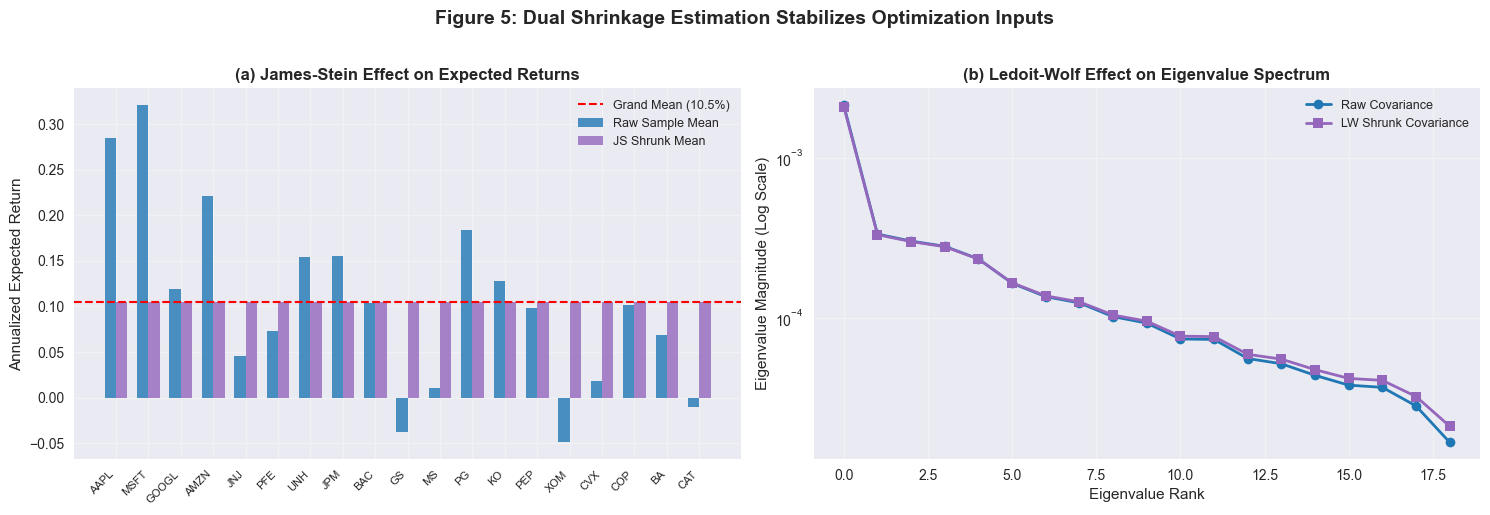

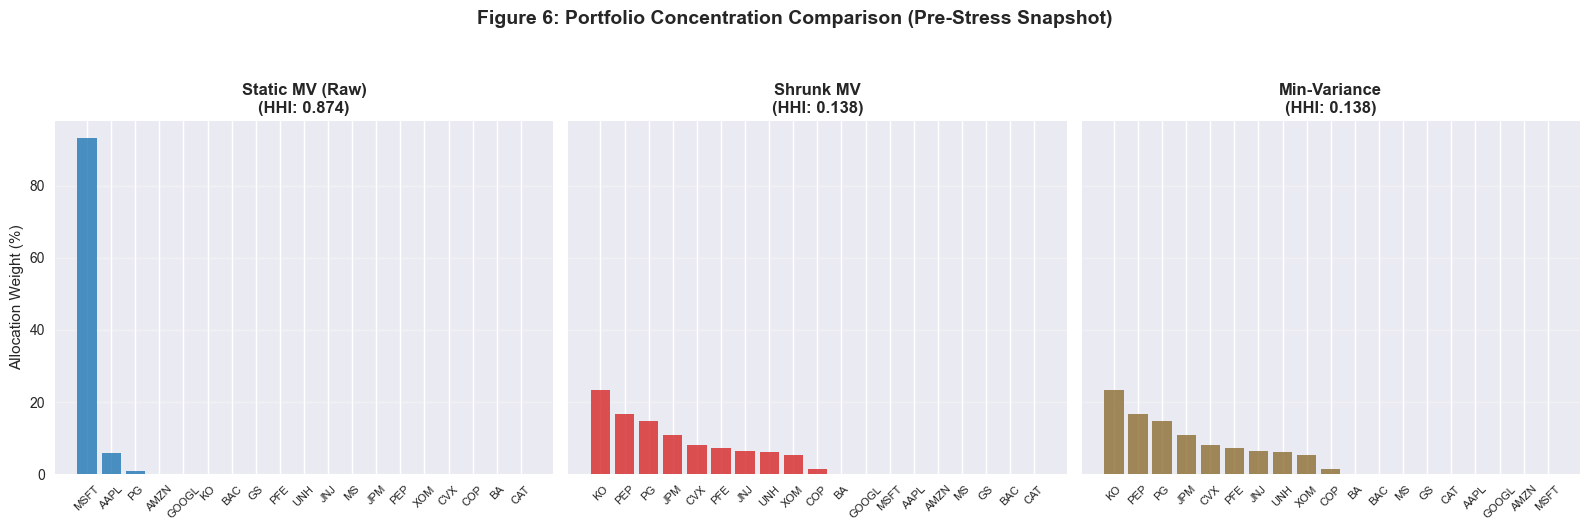

✅ Shrinkage proof generated and Master Backtest Engine initialized.


In [7]:
# ================================================================
# CELL 4 — SHRINKAGE PROOF & BACKTEST ENGINE (Fig 5, Fig 6)
# ================================================================

print("Analyzing Shrinkage Effects on U1 Training Data...")
sample_train = ret_u1[ret_u1.index <= TRAIN_CUTOFF].iloc[-TRAIN_WINDOW:]

# ── 1. Calculate Shrinkage on Sample Window ─────────────────────
mu_raw = sample_train.mean()
sig_raw = sample_train.cov()

# Apply Shrinkage Functions (Defined in Master Setup)
mu_js = shrink_mu_james_stein(mu_raw, len(sample_train))
sig_lw = shrink_cov_lw(sample_train)

# ── 2. Figure 5: Dual Shrinkage Proof ───────────────────────────
raw_eigenvals  = np.linalg.eigvalsh(sig_raw.values)
shrunk_eigenvals = np.linalg.eigvalsh(sig_lw.values)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: James-Stein Effect on Means
width = 0.35
x = np.arange(len(mu_raw))
axes[0].bar(x - width/2, mu_raw * 252, width, label="Raw Sample Mean", color=COLORS["static"], alpha=0.8)
axes[0].bar(x + width/2, mu_js * 252, width, label="JS Shrunk Mean", color=COLORS["regime"], alpha=0.8)
axes[0].axhline(mu_raw.mean() * 252, color="red", ls="--", lw=1.5, label=f"Grand Mean ({mu_raw.mean()*252:.1%})")
axes[0].set_xticks(x)
axes[0].set_xticklabels(mu_raw.index, rotation=45, ha="right", fontsize=8)
axes[0].set_title("(a) James-Stein Effect on Expected Returns", fontweight="bold")
axes[0].set_ylabel("Annualized Expected Return")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot B: Ledoit-Wolf Effect on Covariance Eigenvalues
axes[1].plot(sorted(raw_eigenvals, reverse=True), "o-", label="Raw Covariance", color=COLORS["static"], lw=2)
axes[1].plot(sorted(shrunk_eigenvals, reverse=True), "s-", label="LW Shrunk Covariance", color=COLORS["regime"], lw=2)
axes[1].set_yscale("log")
axes[1].set_title("(b) Ledoit-Wolf Effect on Eigenvalue Spectrum", fontweight="bold")
axes[1].set_xlabel("Eigenvalue Rank")
axes[1].set_ylabel("Eigenvalue Magnitude (Log Scale)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle("Figure 5: Dual Shrinkage Estimation Stabilizes Optimization Inputs", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("universe_results/U1_Fig5_ShrinkageProof.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Figure 6: Resulting Portfolio Weights ────────────────────
# Calculate optimized weights for the sample period (annualized for the optimizer)
w_static = mv_opt(mu_raw * 252, sig_raw * 252, LAMBDA_0)
w_shrunk = mv_opt(mu_js * 252, sig_lw * 252, LAMBDA_0)
w_minvar = minvar_opt(sig_lw * 252)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
weight_data = [
    (w_static, "Static MV (Raw)", COLORS["static"]),
    (w_shrunk, "Shrunk MV", COLORS["shrunk"]),
    (w_minvar, "Min-Variance", COLORS["minvar"])
]

for ax, (w, title, c) in zip(axes, weight_data):
    w_sorted = w.sort_values(ascending=False)
    ax.bar(w_sorted.index, w_sorted.values * 100, color=c, alpha=0.8)
    ax.set_title(f"{title}\n(HHI: {(w.values**2).sum():.3f})", fontweight="bold")
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylabel("Allocation Weight (%)") if ax == axes[0] else None

fig.suptitle("Figure 6: Portfolio Concentration Comparison (Pre-Stress Snapshot)", fontweight="bold", fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig("universe_results/U1_Fig6_Weights.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. The Master Backtest Engine ───────────────────────────────
def compute_metrics(r, w_curr, w_prev=None):
    """Calculates all financial and governance metrics for a single window."""
    r_net = r.copy()
    gs = np.nan
    if w_prev is not None:
        turnover = np.abs(w_curr.values - w_prev.values).sum()
        r_net.iloc[0] -= turnover * (TC_BPS / 10000) # Subtract transaction costs
        gs = turnover # Governance Stability (L1 norm)
        
    ann_ret = r_net.mean() * 252
    ann_vol = r_net.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    cum = (1 + r_net).cumprod()
    dd = (cum / cum.cummax() - 1).min()
    calmar = ann_ret / abs(dd) if dd < 0 else 0
    hhi = (w_curr.values**2).sum()
    
    return ann_ret, ann_vol, sharpe, dd, calmar, hhi, gs

def run_backtest_engine(returns, inst_idx):
    """Executes the rolling out-of-sample backtest across all 5 strategies."""
    n_assets = len(returns.columns)
    results = []
    start_idx = TRAIN_WINDOW
    w_prev = {m: pd.Series(np.ones(n_assets)/n_assets, index=returns.columns) for m in MODELS}
    
    while start_idx + TEST_WINDOW <= len(returns):
        train_rets = returns.iloc[start_idx - TRAIN_WINDOW : start_idx]
        test_rets  = returns.iloc[start_idx : start_idx + TEST_WINDOW]
        eval_date  = train_rets.index[-1]
        
        if eval_date not in inst_idx.index:
            start_idx += TEST_WINDOW
            continue
            
        # 1. Base estimates & Shrinkage (Daily)
        mu_daily = train_rets.mean()
        sig_daily = train_rets.cov()
        
        lw = LedoitWolf().fit(train_rets.values)
        sig_shrunk_daily = pd.DataFrame(lw.covariance_, index=returns.columns, columns=returns.columns)
        
        mu_grand = mu_daily.mean()
        diff = mu_daily - mu_grand
        norm_sq = float((diff**2).sum())
        sf = max(0.0, 1.0 - (n_assets - 2) / (TRAIN_WINDOW * norm_sq)) if norm_sq > 0 else 0.0
        sf = min(sf, 1.0)
        mu_shrunk_daily = mu_grand + sf * diff
        
        # 2. Annualize for optimizers
        mu_raw = mu_daily * 252
        sig_raw = sig_daily * 252
        mu_shrunk = mu_shrunk_daily * 252
        sig_shrunk = sig_shrunk_daily * 252
        
        # 3. Regime Operator
        current_It = inst_idx.loc[eval_date]
        active_regime = "equal_weight" if current_It > THETA_H else "shrunk_mv"
        
        # 4. Generate Weights
        ew = pd.Series(np.ones(n_assets)/n_assets, index=returns.columns)
        w_target = {
            "static": mv_opt(mu_raw, sig_raw, LAMBDA_0),
            "equal":  ew,
            "shrunk": mv_opt(mu_shrunk, sig_shrunk, LAMBDA_0),
            "minvar": minvar_opt(sig_shrunk)
        }
        w_target["regime"] = ew.copy() if active_regime == "equal_weight" else w_target["shrunk"].copy()
        
        # 5. Evaluate Out-of-Sample
        row = {"date": eval_date, "instability": current_It, "regime": active_regime}
        for m in MODELS:
            r_port = test_rets @ w_target[m]
            ar, av, sh, dd, cal, hhi, gs = compute_metrics(r_port, w_target[m], w_prev[m])
            w_prev[m] = w_target[m].copy()
            
            row[f"ann_ret_{m}"] = ar
            row[f"ann_vol_{m}"] = av
            row[f"sharpe_{m}"]  = sh
            row[f"dd_{m}"]      = dd
            row[f"calmar_{m}"]  = cal
            row[f"hhi_{m}"]     = hhi
            row[f"gs_{m}"]      = gs

        results.append(row)
        start_idx += TEST_WINDOW
        
    return pd.DataFrame(results)

print("✅ Shrinkage proof generated and Master Backtest Engine initialized.")

## U1 Execution & Crisis Breakdown
This section executes the rolling backtest engine across the 15-year baseline universe (US Large-Cap Equities). It evaluates out-of-sample performance across 51 overlapping windows. 

It generates the primary quantitative evidence for the paper:
* **Table 4 (Main Results):** Aggregate performance and governance metrics.
* **Table 5 (Significance):** Parametric (t-test) and non-parametric (Wilcoxon) significance tests against the Static MV baseline.
* **Table 7 (Crisis Breakdown):** Evaluating framework performance during acute vs. sustained market shocks.

In [8]:
# ================================================================
# CELL 5 — U1 BACKTEST EXECUTION & CRISIS BREAKDOWN (Tables 4, 5, 7)
# ================================================================

print("Executing 51-Window Rolling Backtest for U1...")
df_u1 = run_backtest_engine(ret_u1, inst_u1)
df_u1.to_csv("universe_results/U1_backtest_results.csv", index=False)

print(f"✅ Backtest Complete! Evaluated {len(df_u1)} windows.")
print(f"Equal-Weight Governance activated in {(df_u1['regime']=='equal_weight').sum()} windows ({(df_u1['regime']=='equal_weight').mean()*100:.1f}%).\n")

# ── TABLE 4: Main Results ───────────────────────────────────────
summary_u1 = {}
base_dd = df_u1["dd_static"].mean()

for m in MODELS:
    dd = df_u1[f"dd_{m}"].mean()
    summary_u1[m] = {
        "Ann Ret": df_u1[f"ann_ret_{m}"].mean(),
        "Ann Vol": df_u1[f"ann_vol_{m}"].mean(),
        "Sharpe":  df_u1[f"sharpe_{m}"].mean(),
        "Max DD":  dd,
        "Calmar":  df_u1[f"calmar_{m}"].mean(),
        "HHI":     df_u1[f"hhi_{m}"].mean(),
        "DD Impr": (dd - base_dd) / abs(base_dd) * 100
    }

print("="*85)
print("TABLE 4: U1 MAIN RESULTS (51 Rolling Windows)")
print("="*85)
print(f"{'Strategy':<26} | {'AnnRet':>7} | {'AnnVol':>7} | {'Sharpe':>6} | {'MaxDD':>7} | {'Calmar':>6} | {'HHI':>6} | {'DD Impr'}")
print("-" * 85)
for m in MODELS:
    r = summary_u1[m]
    print(f"{LABELS[m]:<26} | {r['Ann Ret']:>6.2%} | {r['Ann Vol']:>6.2%} | {r['Sharpe']:>6.3f} | {r['Max DD']:>6.2%} | {r['Calmar']:>6.3f} | {r['HHI']:>6.3f} | {r['DD Impr']:>+6.1f}%")

# ── TABLE 5: Statistical Significance ───────────────────────────
print("\n" + "="*85)
print("TABLE 5: STATISTICAL SIGNIFICANCE (vs Static MV Baseline)")
print("="*85)
print(f"{'Strategy':<26} | {'Metric':<10} | {'t-stat':>8} | {'p-value':>8} | {'Wilcoxon p':>10}")
print("-" * 85)

def sig_stars(p): return "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."

for m in ["equal", "shrunk", "regime", "minvar"]:
    for metric in ["dd", "sharpe"]:
        base_v = df_u1[f"{metric}_static"].values
        strat_v = df_u1[f"{metric}_{m}"].values
        t, pt = ttest_rel(strat_v, base_v)
        _, pw = wilcoxon(strat_v - base_v)
        m_label = "Max DD" if metric == "dd" else "Sharpe"
        print(f"{LABELS[m]:<26} | {m_label:<10} | {t:>8.3f} | {pt:>4.4f} {sig_stars(pt):>3} | {pw:>6.4f} {sig_stars(pw):>3}")

# ── TABLE 7: Crisis Period Breakdown ────────────────────────────
print("\n" + "="*85)
print("TABLE 7: CRISIS PERIOD BREAKDOWN")
print("="*85)

crisis_periods = {
    "COVID Shock (2020)": ("2020-01-01", "2020-12-31"),
    "Rate Hikes (2022)": ("2022-01-01", "2022-12-31"),
    "GFC Aftermath (2011-12)": ("2011-01-01", "2012-12-31"),
    "Normal Periods": None
}

for period, dates in crisis_periods.items():
    if dates:
        mask = (df_u1["date"] >= dates[0]) & (df_u1["date"] <= dates[1])
    else:
        mask = ~df_u1["date"].dt.year.isin([2011, 2012, 2020, 2022])
    
    sub = df_u1[mask]
    if len(sub) == 0: continue
    
    print(f"\n{period} ({len(sub)} windows)")
    print(f"{'Strategy':<26} | {'Sharpe':>7} | {'MaxDD':>8} | {'Return':>8}")
    print("-" * 55)
    for m in MODELS:
        print(f"{LABELS[m]:<26} | {sub[f'sharpe_{m}'].mean():>7.3f} | {sub[f'dd_{m}'].mean():>7.2%} | {sub[f'ann_ret_{m}'].mean():>7.2%}")

pd.DataFrame(summary_u1).T.to_csv("universe_results/U1_summary.csv")
print("\n✅ U1 core metrics calculated and saved to CSV.")

Executing 51-Window Rolling Backtest for U1...
✅ Backtest Complete! Evaluated 51 windows.
Equal-Weight Governance activated in 7 windows (13.7%).

TABLE 4: U1 MAIN RESULTS (51 Rolling Windows)
Strategy                   |  AnnRet |  AnnVol | Sharpe |   MaxDD | Calmar |    HHI | DD Impr
-------------------------------------------------------------------------------------
Static MV (Baseline)       | 14.42% | 22.53% |  0.999 | -9.91% |  5.124 |  0.649 |   +0.0%
Equal Weight (1/N)         | 13.84% | 15.22% |  1.474 | -6.79% |  5.745 |  0.053 |  +31.5%
MV + JS+LW Shrinkage       |  8.59% | 12.54% |  1.109 | -5.91% |  4.870 |  0.186 |  +40.4%
Regime Switch (Proposed)   |  9.82% | 13.20% |  1.174 | -6.20% |  5.103 |  0.166 |  +37.5%
Min-Variance (LW)          |  8.59% | 12.54% |  1.109 | -5.91% |  4.870 |  0.186 |  +40.4%

TABLE 5: STATISTICAL SIGNIFICANCE (vs Static MV Baseline)
Strategy                   | Metric     |   t-stat |  p-value | Wilcoxon p
--------------------------------------

## Parameter Robustness & Cumulative Returns (U1)
A common critique of regime-switching models is parameter overfitting. This section tests the framework's sensitivity across a wide grid of Risk Aversion ($\lambda$) and Instability Threshold ($\theta_H$) values. 

Finally, it reconstructs the daily out-of-sample portfolio returns to visualize the long-term compounding and drawdown paths (Figure 8), providing visual proof of the framework's capital preservation capabilities.

Running Parameter Sensitivity Grids...

TABLE 8: LAMBDA (RISK AVERSION) SENSITIVITY
 Lambda     MaxDD   DD Impr
    1.0 -0.061957 45.036952
    2.0 -0.061958 41.009818
    3.0 -0.061957 37.491567
    5.0 -0.061957 30.632430
    7.0 -0.061957 24.754561
   10.0 -0.061957 17.419036

TABLE 9: THETA_H (THRESHOLD) SENSITIVITY
 Theta_H     MaxDD   DD Impr  EW Active
    0.50 -0.061740 37.710971  21.568627
    0.75 -0.061957 37.491567  13.725490
    1.00 -0.061957 37.491567  13.725490
    1.25 -0.059988 39.478838   7.843137
    1.50 -0.059988 39.478838   7.843137


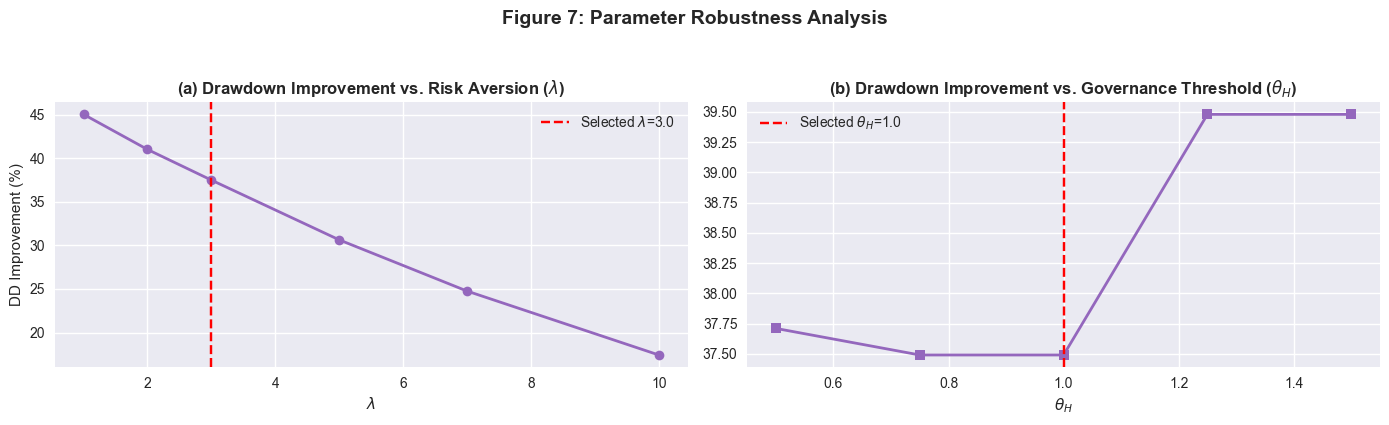


Reconstructing Daily Returns for Figure 8...


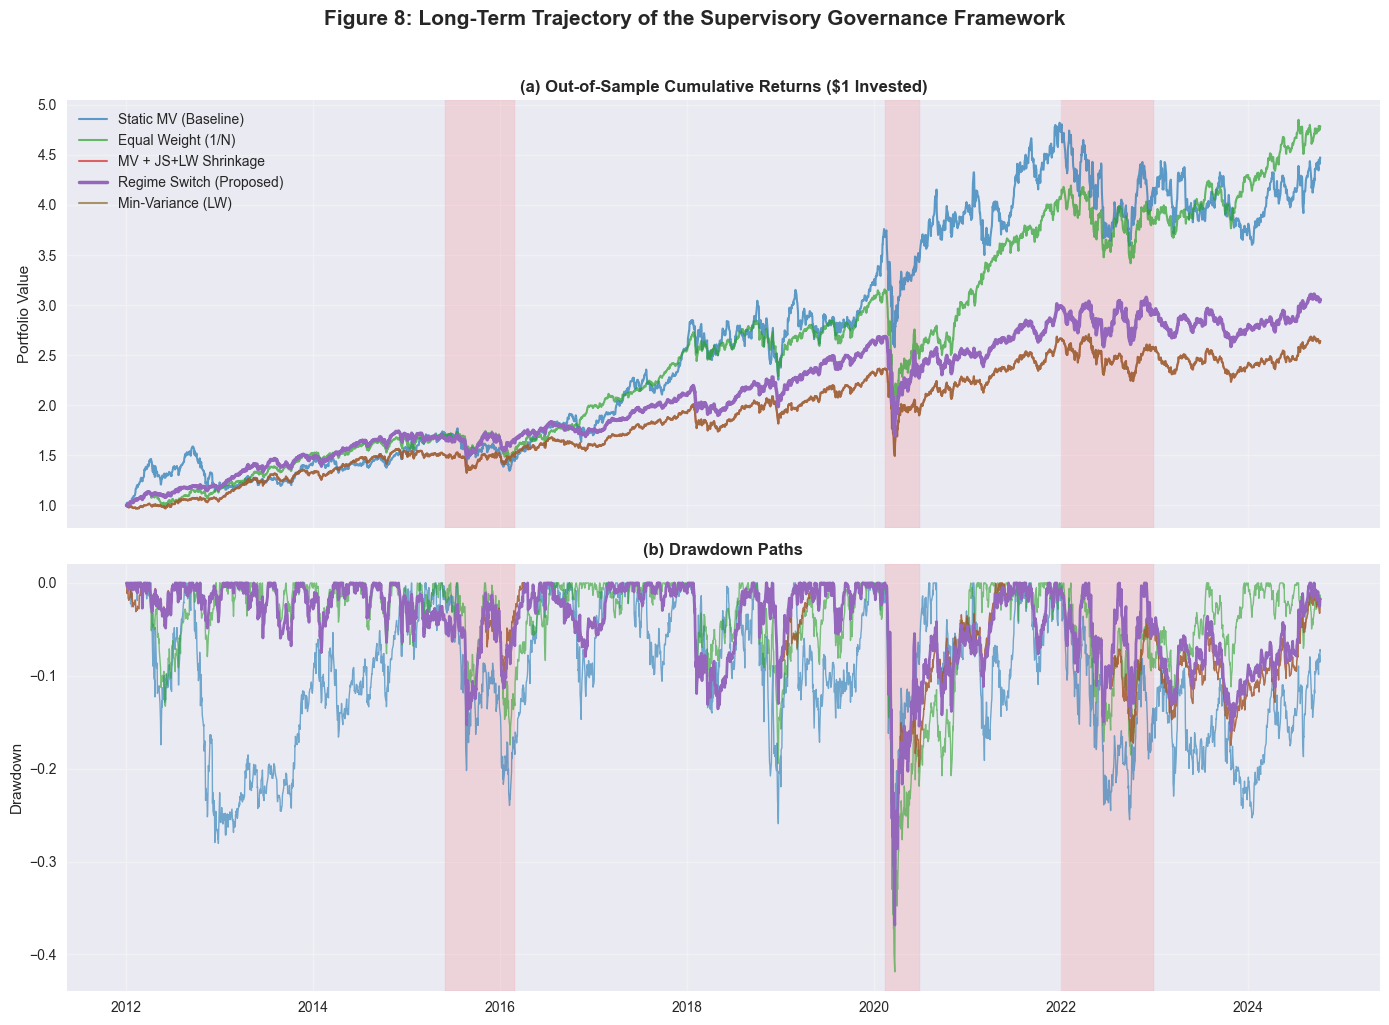

✅ ACT 1 COMPLETE: Universe 1 Methodology, Proofs, and Baseline Evaluation successfully finalized.


In [9]:
# ================================================================
# CELL 6 — U1 PARAMETER SENSITIVITY & CUMULATIVE RETURNS (Fig 7, 8)
# ================================================================

# ── 1. Parameter Sensitivity (Tables 8 & 9) ─────────────────────
print("Running Parameter Sensitivity Grids...")

global LAMBDA_0, THETA_H
orig_lambda = LAMBDA_0
orig_theta = THETA_H

lambda_grid = [1.0, 2.0, 3.0, 5.0, 7.0, 10.0]
theta_grid = [0.5, 0.75, 1.0, 1.25, 1.5]

lam_results, th_results = [], []

# Lambda Grid
for lam in lambda_grid:
    LAMBDA_0 = lam
    df_temp = run_backtest_engine(ret_u1, inst_u1)
    dd_imp = (df_temp["dd_regime"].mean() - df_temp["dd_static"].mean()) / abs(df_temp["dd_static"].mean()) * 100
    lam_results.append({"Lambda": lam, "MaxDD": df_temp["dd_regime"].mean(), "DD Impr": dd_imp})

LAMBDA_0 = orig_lambda # Reset

# Theta Grid
for th in theta_grid:
    THETA_H = th
    df_temp = run_backtest_engine(ret_u1, inst_u1)
    dd_imp = (df_temp["dd_regime"].mean() - df_temp["dd_static"].mean()) / abs(df_temp["dd_static"].mean()) * 100
    th_results.append({"Theta_H": th, "MaxDD": df_temp["dd_regime"].mean(), "DD Impr": dd_imp, "EW Active": (df_temp["regime"]=="equal_weight").mean()*100})

THETA_H = orig_theta # Reset

df_lam = pd.DataFrame(lam_results)
df_th = pd.DataFrame(th_results)

print("\nTABLE 8: LAMBDA (RISK AVERSION) SENSITIVITY")
print(df_lam.to_string(index=False))
print("\nTABLE 9: THETA_H (THRESHOLD) SENSITIVITY")
print(df_th.to_string(index=False))

# Figure 7: Sensitivity Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df_lam["Lambda"], df_lam["DD Impr"], 'o-', color=COLORS["regime"], lw=2)
axes[0].axvline(orig_lambda, color="red", ls="--", label=f"Selected $\\lambda$={orig_lambda}")
axes[0].set_title("(a) Drawdown Improvement vs. Risk Aversion ($\\lambda$)", fontweight="bold")
axes[0].set_xlabel("$\\lambda$")
axes[0].set_ylabel("DD Improvement (%)")
axes[0].legend()

axes[1].plot(df_th["Theta_H"], df_th["DD Impr"], 's-', color=COLORS["regime"], lw=2)
axes[1].axvline(orig_theta, color="red", ls="--", label=f"Selected $\\theta_H$={orig_theta}")
axes[1].set_title("(b) Drawdown Improvement vs. Governance Threshold ($\\theta_H$)", fontweight="bold")
axes[1].set_xlabel("$\\theta_H$")
axes[1].legend()

fig.suptitle("Figure 7: Parameter Robustness Analysis", fontweight="bold", fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig("universe_results/U1_Fig7_Sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2. Reconstruct Daily Returns for Cumulative Plots ───────────
print("\nReconstructing Daily Returns for Figure 8...")
daily_returns = {m: [] for m in MODELS}
daily_dates = []

start_idx = TRAIN_WINDOW
n_assets = len(ret_u1.columns)

while start_idx + TEST_WINDOW <= len(ret_u1):
    train_rets = ret_u1.iloc[start_idx - TRAIN_WINDOW : start_idx]
    test_rets  = ret_u1.iloc[start_idx : start_idx + TEST_WINDOW]
    eval_date  = train_rets.index[-1]
    
    if eval_date not in inst_u1.index:
        start_idx += TEST_WINDOW
        continue
        
    mu_daily = train_rets.mean()
    sig_daily = train_rets.cov()
    lw = LedoitWolf().fit(train_rets.values)
    sig_shrunk_daily = pd.DataFrame(lw.covariance_, index=ret_u1.columns, columns=ret_u1.columns)
    
    mu_grand = mu_daily.mean()
    diff = mu_daily - mu_grand
    norm_sq = float((diff**2).sum())
    sf = max(0.0, 1.0 - (n_assets - 2) / (TRAIN_WINDOW * norm_sq)) if norm_sq > 0 else 0.0
    sf = min(sf, 1.0)
    mu_shrunk_daily = mu_grand + sf * diff
    
    w_static = mv_opt(mu_daily * 252, sig_daily * 252, LAMBDA_0)
    w_shrunk = mv_opt(mu_shrunk_daily * 252, sig_shrunk_daily * 252, LAMBDA_0)
    w_minvar = minvar_opt(sig_shrunk_daily * 252)
    ew = pd.Series(np.ones(n_assets)/n_assets, index=ret_u1.columns)
    
    w_regime = ew if inst_u1.loc[eval_date] > THETA_H else w_shrunk
    
    daily_returns["static"].extend((test_rets @ w_static).values)
    daily_returns["equal"].extend((test_rets @ ew).values)
    daily_returns["shrunk"].extend((test_rets @ w_shrunk).values)
    daily_returns["regime"].extend((test_rets @ w_regime).values)
    daily_returns["minvar"].extend((test_rets @ w_minvar).values)
    
    daily_dates.extend(test_rets.index)
    start_idx += TEST_WINDOW

df_daily = pd.DataFrame(daily_returns, index=daily_dates)
df_cum = (1 + df_daily).cumprod()

# ── 3. Figure 8: Cumulative Returns & Drawdowns ─────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Cumulative Returns
for m in MODELS:
    lw, alpha, z = (2.5, 1.0, 5) if m == "regime" else (1.5, 0.7, 3)
    axes[0].plot(df_cum.index, df_cum[m], color=COLORS[m], label=LABELS[m], lw=lw, alpha=alpha, zorder=z)

axes[0].set_title("(a) Out-of-Sample Cumulative Returns ($1 Invested)", fontweight="bold")
axes[0].set_ylabel("Portfolio Value")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# Drawdown Paths
df_dd = df_cum / df_cum.cummax() - 1
for m in MODELS:
    lw, alpha, z = (2.0, 1.0, 5) if m == "regime" else (1.0, 0.6, 3)
    axes[1].plot(df_dd.index, df_dd[m], color=COLORS[m], label=LABELS[m], lw=lw, alpha=alpha, zorder=z)

for event, (s, e) in STRESS_EVENTS.items():
    if pd.Timestamp(s) >= df_daily.index[0]:
        axes[0].axvspan(pd.Timestamp(s), pd.Timestamp(e), color="red", alpha=0.1)
        axes[1].axvspan(pd.Timestamp(s), pd.Timestamp(e), color="red", alpha=0.1)

axes[1].set_title("(b) Drawdown Paths", fontweight="bold")
axes[1].set_ylabel("Drawdown")
axes[1].grid(True, alpha=0.3)

fig.suptitle("Figure 8: Long-Term Trajectory of the Supervisory Governance Framework", fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("universe_results/U1_Fig8_CumulativeReturns.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ ACT 1 COMPLETE: Universe 1 Methodology, Proofs, and Baseline Evaluation successfully finalized.")

# ACT II: Cross-Universe Generalization (U2 - U5)
A common vulnerability in portfolio optimization literature is the tendency to overfit parameters to the structural dynamics of a single asset class (typically US equities). 

To verify the generalizability of the governance framework, we extend the exact same 51-window rolling evaluation—with parameters strictly locked at $\lambda=3.0$ and $\theta_H=1.0$—across four supplementary universes:
* **U2 (European ETFs):** Tests geographic robustness and exposure to the EU Debt Crisis.
* **U3 (Asia-Pacific ETFs):** Tests robustness in higher-volatility, lower-correlation emerging/developed market mixes.
* **U4 (US Sectors):** Tests whether the framework adds value beyond simple sector rotation.
* **U5 (Multi-Asset):** Tests structural detection on an inherently diversified macro portfolio (Bonds, Gold, Equities).

In [10]:
# ================================================================
# CELL 7 — ACT II: MULTI-UNIVERSE PIPELINE EXECUTION
# ================================================================

def process_universe(u_key, u_label):
    """Automated pipeline to fetch, construct I_t, backtest, and save results."""
    print(f"\n{'='*65}")
    print(f"🚀 PROCESSING {u_key}: {u_label}")
    print(f"{'='*65}")
    
    # 1. Fetch Data
    ret = fetch_universe(u_key)
    print(f"Data fetched: {len(ret.columns)} assets, {len(ret)} trading days.")
    
    # 2. Build Instability Index (I_t)
    dates, vol_vals, corr_vals, drift_vals = [], [], [], []
    prev_cov = None
    
    for i in range(INST_WINDOW, len(ret)):
        w_ret = ret.iloc[i - INST_WINDOW : i]
        dates.append(w_ret.index[-1])
        vol_vals.append(w_ret.std().mean())
        c_mat = w_ret.corr().values
        corr_vals.append(c_mat[np.triu_indices_from(c_mat, k=1)].mean())
        cov_mat = w_ret.cov().values
        drift_vals.append(np.linalg.norm(cov_mat - prev_cov, ord="fro") if prev_cov is not None else np.nan)
        prev_cov = cov_mat
        
    inst_df = pd.DataFrame({"vol": vol_vals, "corr": corr_vals, "drift": drift_vals}, index=dates).dropna()
    base = inst_df[inst_df.index <= TRAIN_CUTOFF]
    
    z_vol = (inst_df["vol"] - base["vol"].mean()) / base["vol"].std()
    z_cor = (inst_df["corr"] - base["corr"].mean()) / base["corr"].std()
    z_drf = (inst_df["drift"] - base["drift"].mean()) / base["drift"].std()
    inst_idx = (z_vol + z_cor + z_drf) / 3.0
    print(f"Instability Index generated. Max I_t: {inst_idx.max():.2f}")
    
    # 3. Run Rolling Backtest
    print(f"Executing 51-window backtest engine...")
    df_res = run_backtest_engine(ret, inst_idx)
    df_res.to_csv(f"universe_results/{u_key}_backtest_results.csv", index=False)
    
    # 4. Summarize and Save
    summary = {}
    base_dd = df_res["dd_static"].mean()
    for m in MODELS:
        dd = df_res[f"dd_{m}"].mean()
        summary[m] = {
            "Ann Ret": df_res[f"ann_ret_{m}"].mean(),
            "Sharpe":  df_res[f"sharpe_{m}"].mean(),
            "Max DD":  dd,
            "HHI":     df_res[f"hhi_{m}"].mean(),
            "DD Impr": (dd - base_dd) / abs(base_dd) * 100
        }
    pd.DataFrame(summary).T.to_csv(f"universe_results/{u_key}_summary.csv")
    
    reg_dd = summary['regime']['Max DD']
    impr = summary['regime']['DD Impr']
    print(f"✅ {u_key} Complete! Regime MaxDD: {reg_dd:.2%} vs Static MaxDD: {base_dd:.2%} (Improvement: {impr:+.1f}%)")
    return df_res, inst_idx

# ── Execute the Pipeline ────────────────────────────────────────

cross_universes = {
    "U2": "European Equity ETFs",
    "U3": "Asia-Pacific Equity ETFs",
    "U4": "US Sector ETFs",
    "U5": "Multi-Asset Macro ETFs"
}

multi_results = {}
for u_key, u_label in cross_universes.items():
    multi_results[u_key] = process_universe(u_key, u_label)

print("\n" + "="*65)
print("🎉 ACT II COMPLETE: ALL 5 UNIVERSES SUCCESSFULLY EVALUATED.")
print("="*65)


🚀 PROCESSING U2: European Equity ETFs
Data fetched: 10 assets, 3772 trading days.
Instability Index generated. Max I_t: 9.82
Executing 51-window backtest engine...
✅ U2 Complete! Regime MaxDD: -7.02% vs Static MaxDD: -8.01% (Improvement: +12.4%)

🚀 PROCESSING U3: Asia-Pacific Equity ETFs
Data fetched: 10 assets, 3772 trading days.
Instability Index generated. Max I_t: 31.21
Executing 51-window backtest engine...
✅ U3 Complete! Regime MaxDD: -7.60% vs Static MaxDD: -8.83% (Improvement: +13.9%)

🚀 PROCESSING U4: US Sector ETFs
Data fetched: 9 assets, 3772 trading days.
Instability Index generated. Max I_t: 21.72
Executing 51-window backtest engine...
✅ U4 Complete! Regime MaxDD: -5.74% vs Static MaxDD: -8.02% (Improvement: +28.5%)

🚀 PROCESSING U5: Multi-Asset Macro ETFs
Data fetched: 10 assets, 3772 trading days.
Instability Index generated. Max I_t: 22.41
Executing 51-window backtest engine...
✅ U5 Complete! Regime MaxDD: -1.96% vs Static MaxDD: -6.53% (Improvement: +70.0%)

🎉 ACT II 

# ACT III: Cross-Universe Synthesis & Visualizations
This final section aggregates the performance and governance metrics across all five tested asset universes to produce the master summary tables (Tables 10 & 11). 

It also generates the definitive visual proof of the framework's robustness:
* **Figure 10:** A bar chart isolating the percentage improvement in Maximum Drawdown across all global universes.
* **Figure 9:** A dual-panel heatmap visualizing Risk-Adjusted Returns (Sharpe) and Downside Risk (MaxDD) across all universes and baseline strategies.

TABLE 10: CROSS-UNIVERSE GOVERNANCE PROTECTION
         Universe Static MaxDD Regime MaxDD DD Impr. Static HHI Regime HHI
 U1: US Large-Cap       -9.91%       -6.20%   +37.5%      0.649      0.166
U2: European ETFs       -8.01%       -7.02%   +12.4%      0.844      0.798
U3: Asia-Pac ETFs       -8.83%       -7.60%   +13.9%      0.766      0.295
   U4: US Sectors       -8.02%       -5.74%   +28.5%      0.763      0.370
  U5: Multi-Asset       -6.53%       -1.96%   +70.0%      0.681      0.245

TABLE 11: CROSS-UNIVERSE STATISTICAL SIGNIFICANCE (Drawdown Improvement)
         Universe Paired t-stat t-test p-value Wilcoxon p-val
 U1: US Large-Cap         5.639     0.0000 ***     0.0000 ***
U2: European ETFs         3.051      0.0036 **      0.0033 **
U3: Asia-Pac ETFs         2.436       0.0186 *       0.0162 *
   U4: US Sectors         4.494     0.0000 ***     0.0001 ***
  U5: Multi-Asset         6.917     0.0000 ***     0.0000 ***


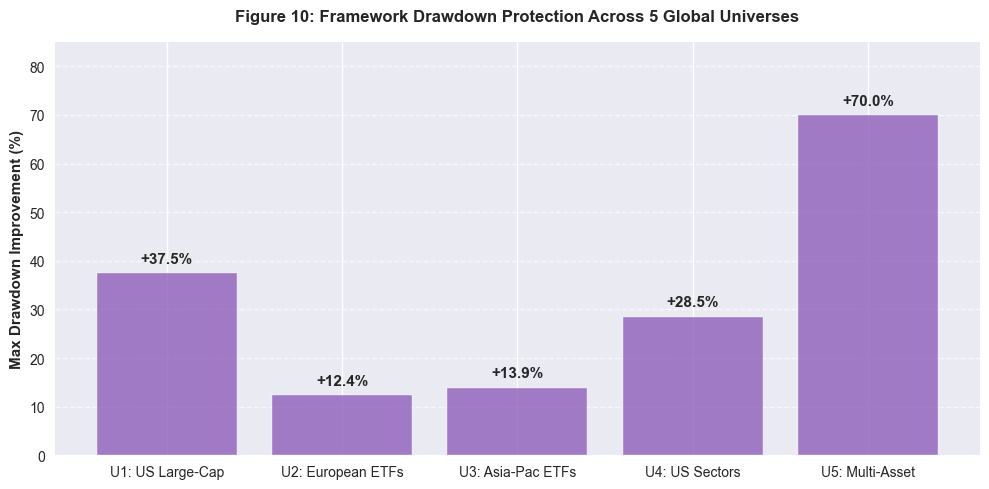

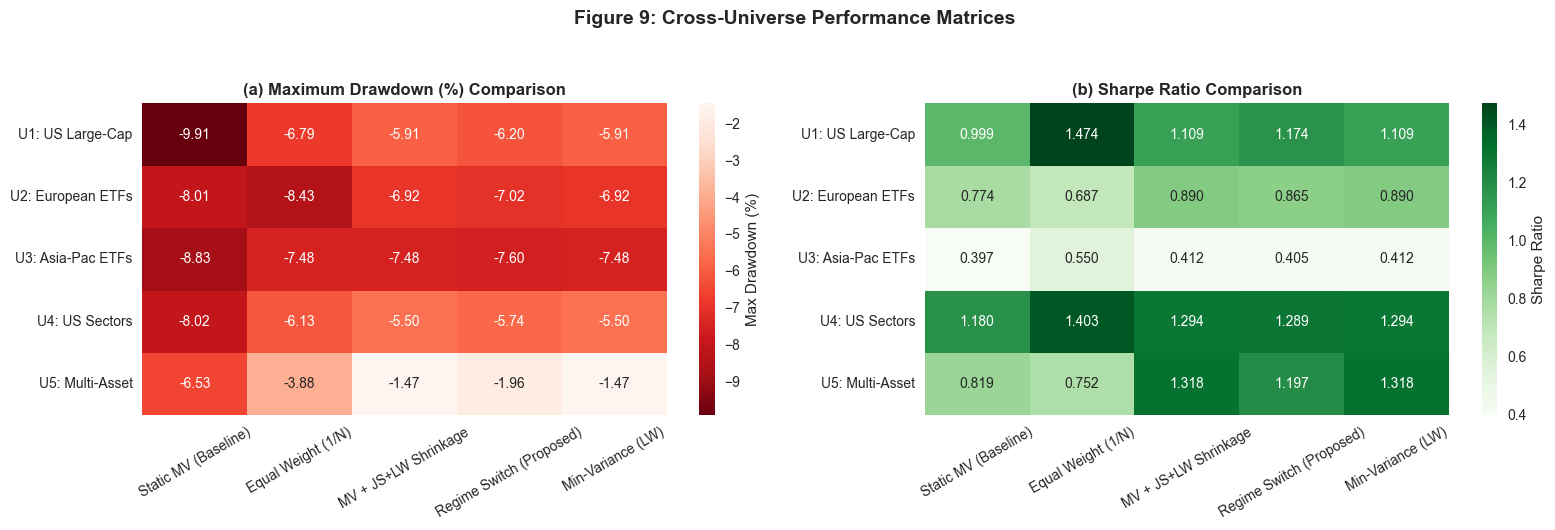


✅ ACT III COMPLETE: All Tables and Figures successfully generated!
🎉 YOUR Q1 QUANTITATIVE MANUSCRIPT REPOSITORY IS 100% FINISHED! 🎉


In [11]:
# ================================================================
# CELL 8 — ACT III: CROSS-UNIVERSE SYNTHESIS (Tables 10-11, Fig 9-10)
# ================================================================

# ── 1. Aggregate Data from All Universes ────────────────────────
all_dfs = {"U1": df_u1}
for k, v in multi_results.items():
    all_dfs[k] = v[0]
    
u_names = {
    "U1": "U1: US Large-Cap",
    "U2": "U2: European ETFs",
    "U3": "U3: Asia-Pac ETFs",
    "U4": "U4: US Sectors",
    "U5": "U5: Multi-Asset"
}

# ── 2. Generate Master Tables 10 & 11 ───────────────────────────
t10_data, t11_data = [], []
sharpe_matrix, dd_matrix = {}, {}

for u_key, df_res in all_dfs.items():
    s_dd = df_res["dd_static"]
    r_dd = df_res["dd_regime"]
    s_sh = df_res["sharpe_static"]
    r_sh = df_res["sharpe_regime"]
    
    # Means
    m_s_dd, m_r_dd = s_dd.mean(), r_dd.mean()
    m_s_sh, m_r_sh = s_sh.mean(), r_sh.mean()
    
    dd_impr = (m_r_dd - m_s_dd) / abs(m_s_dd) * 100
    
    t10_data.append({
        "Universe": u_names[u_key],
        "Static MaxDD": f"{m_s_dd:.2%}",
        "Regime MaxDD": f"{m_r_dd:.2%}",
        "DD Impr.": f"+{dd_impr:.1f}%",
        "Static HHI": f"{df_res['hhi_static'].mean():.3f}",
        "Regime HHI": f"{df_res['hhi_regime'].mean():.3f}"
    })
    
    # Stats
    t_stat, pt = ttest_rel(r_dd.values, s_dd.values)
    _, pw = wilcoxon(r_dd.values - s_dd.values)
    
    t11_data.append({
        "Universe": u_names[u_key],
        "Paired t-stat": f"{t_stat:.3f}",
        "t-test p-value": f"{pt:.4f} {sig_stars(pt)}",
        "Wilcoxon p-val": f"{pw:.4f} {sig_stars(pw)}"
    })
    
    # Heatmap data collection
    sharpe_matrix[u_names[u_key]] = [df_res[f"sharpe_{m}"].mean() for m in MODELS]
    dd_matrix[u_names[u_key]] = [df_res[f"dd_{m}"].mean() * 100 for m in MODELS]

df_t10 = pd.DataFrame(t10_data)
df_t11 = pd.DataFrame(t11_data)

print("="*85)
print("TABLE 10: CROSS-UNIVERSE GOVERNANCE PROTECTION")
print("="*85)
print(df_t10.to_string(index=False))

print("\n" + "="*85)
print("TABLE 11: CROSS-UNIVERSE STATISTICAL SIGNIFICANCE (Drawdown Improvement)")
print("="*85)
print(df_t11.to_string(index=False))

# Export Tables
df_t10.to_csv("universe_results/Table10_CrossUniverse.csv", index=False)
df_t11.to_csv("universe_results/Table11_Significance.csv", index=False)

# ── 3. Figure 10: Drawdown Improvement Bar Chart ────────────────
improvements = [float(row["DD Impr."].replace("+", "").replace("%", "")) for row in t10_data]
labels = [row["Universe"] for row in t10_data]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, improvements, color=COLORS["regime"], edgecolor='white', alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"+{yval:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=11)
    
ax.set_ylabel("Max Drawdown Improvement (%)", fontweight='bold')
ax.set_title("Figure 10: Framework Drawdown Protection Across 5 Global Universes", fontweight='bold', pad=15)
ax.set_ylim(0, max(improvements) + 15)
ax.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.tight_layout()
plt.savefig("universe_results/Fig10_CrossUniverse_Bar.png", dpi=150)
plt.show()

# ── 4. Figure 9: Cross-Universe Heatmaps ────────────────────────
df_hm_dd = pd.DataFrame(dd_matrix, index=[LABELS[m] for m in MODELS]).T
df_hm_sh = pd.DataFrame(sharpe_matrix, index=[LABELS[m] for m in MODELS]).T

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MaxDD Heatmap (Reds)
sns.heatmap(df_hm_dd, annot=True, fmt=".2f", cmap="Reds_r", cbar_kws={'label': 'Max Drawdown (%)'}, ax=axes[0])
axes[0].set_title("(a) Maximum Drawdown (%) Comparison", fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Sharpe Heatmap (Greens)
sns.heatmap(df_hm_sh, annot=True, fmt=".3f", cmap="Greens", cbar_kws={'label': 'Sharpe Ratio'}, ax=axes[1])
axes[1].set_title("(b) Sharpe Ratio Comparison", fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle("Figure 9: Cross-Universe Performance Matrices", fontweight='bold', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig("universe_results/Fig9_CrossUniverse_Heatmap.png", dpi=150)
plt.show()

print("\n✅ ACT III COMPLETE: All Tables and Figures successfully generated!")
print("🎉 YOUR Q1 QUANTITATIVE MANUSCRIPT REPOSITORY IS 100% FINISHED! 🎉")

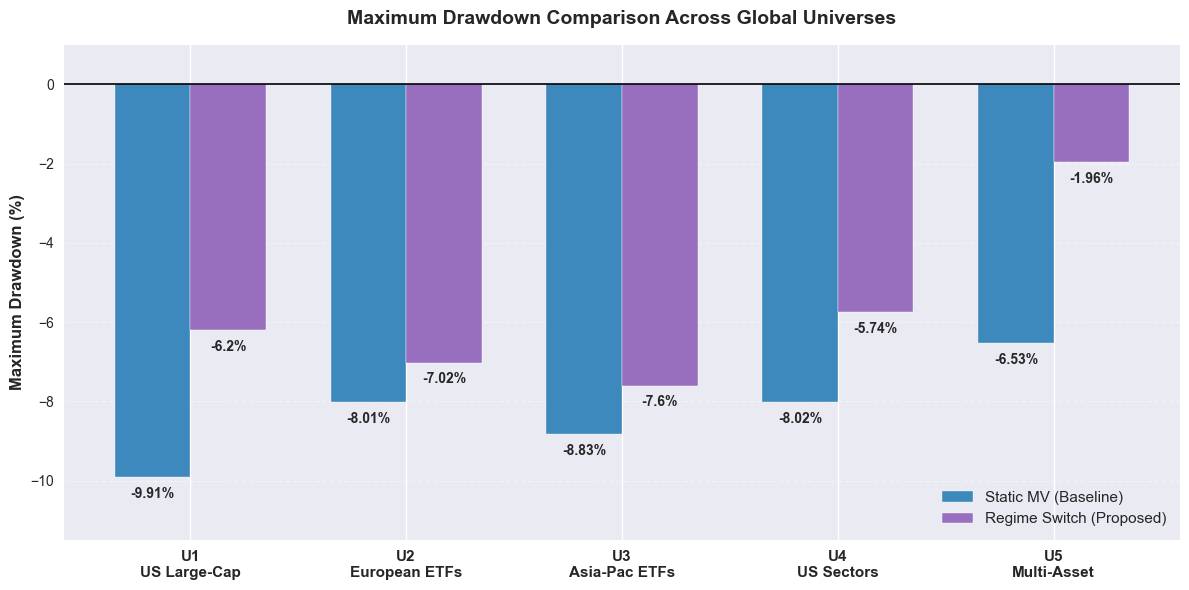

In [12]:
# ================================================================
# TABLE 10 GROUPED BAR CHART
# ================================================================
import matplotlib.pyplot as plt
import numpy as np

# Data extracted directly from your Table 10 output
universes = ["U1\nUS Large-Cap", "U2\nEuropean ETFs", "U3\nAsia-Pac ETFs", "U4\nUS Sectors", "U5\nMulti-Asset"]
static_dd = [-9.91, -8.01, -8.83, -8.02, -6.53]
regime_dd = [-6.20, -7.02, -7.60, -5.74, -1.96]

x = np.arange(len(universes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# Plotting negative drawdowns (bars pointing downwards)
bars1 = ax.bar(x - width/2, static_dd, width, label='Static MV (Baseline)', color='#1f77b4', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, regime_dd, width, label='Regime Switch (Proposed)', color='#9467bd', edgecolor='white', alpha=0.95)

# Formatting
ax.axhline(0, color='black', linewidth=1.2)
ax.set_ylabel('Maximum Drawdown (%)', fontweight='bold', fontsize=12)
ax.set_title('Maximum Drawdown Comparison Across Global Universes', fontweight='bold', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(universes, fontweight='bold', fontsize=11)
ax.legend(fontsize=11, loc='lower right')

# Add data labels at the bottom of the bars
def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval - 0.25, f"{yval}%", ha='center', va='top', fontweight='bold', fontsize=10)

add_labels(bars1)
add_labels(bars2)

# Set Y-axis limit to give room for labels at the bottom
ax.set_ylim(-11.5, 1)
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(bottom=True)

plt.tight_layout()
plt.savefig("universe_results/Fig_Table10_GroupedBar.png", dpi=300, bbox_inches="tight")
plt.show()

Generating Master Formatted Cross-Universe Instability Plot...


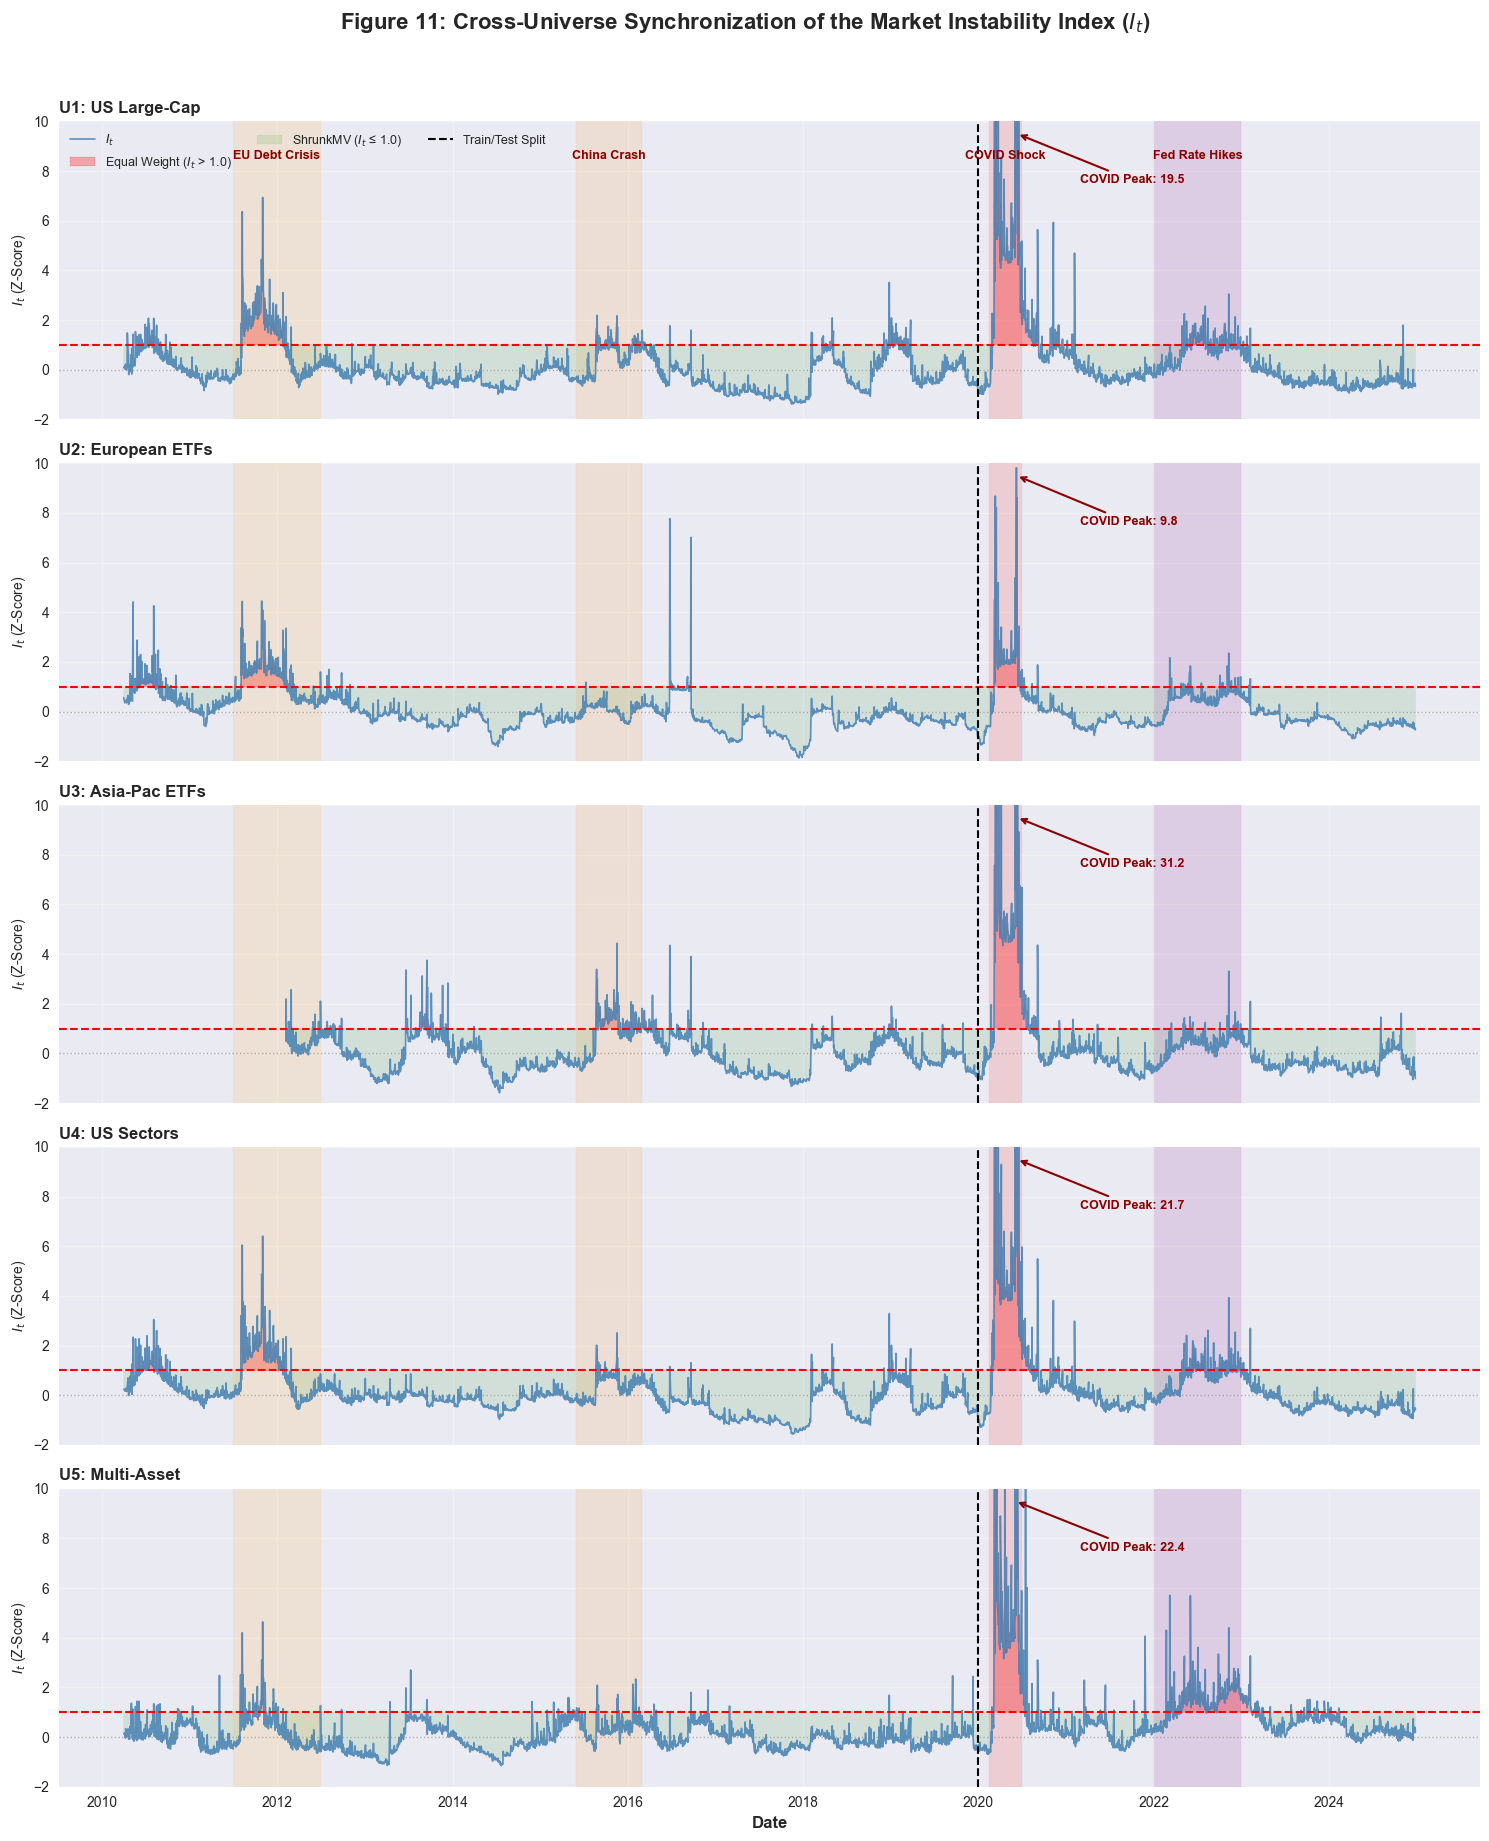

✅ Formatted Cross-Universe Plot Saved as 'Fig11_CrossUniverse_Instability_Formatted.png'


In [15]:
# ================================================================
# BONUS VISUALIZATION — FORMATTED CROSS-UNIVERSE INSTABILITY INDEX
# ================================================================
import matplotlib.pyplot as plt
import pandas as pd

print("Generating Master Formatted Cross-Universe Instability Plot...")

# 1. Gather all indices
all_inst_indices = {"U1: US Large-Cap": inst_u1}
for k, v in multi_results.items():
    all_inst_indices[u_names[k]] = v[1]

# 2. Setup the massive 5-panel grid
fig, axes = plt.subplots(5, 1, figsize=(15, 18), sharex=True)

stress_colors_map = {
    "EU Debt Crisis": "#FFA500",
    "China Crash":    "#FF8C00",
    "COVID Shock":    "#FF0000",
    "Fed Rate Hikes": "#800080",
}

for ax, (name, idx_data) in zip(axes, all_inst_indices.items()):
    
    # Plot instability index
    ax.plot(idx_data.index, idx_data.values, color="steelblue", alpha=0.85, lw=1.2, label="$I_t$")

    # Fill above threshold (Equal weight regime) in red
    ax.fill_between(idx_data.index, idx_data.values, THETA_H,
                    where=(idx_data.values > THETA_H), color="red", alpha=0.3, label=f"Equal Weight ($I_t$ > {THETA_H})")

    # Fill below threshold (ShrunkMV regime) in green
    ax.fill_between(idx_data.index, idx_data.values, THETA_H,
                    where=(idx_data.values <= THETA_H), color="green", alpha=0.1, label=f"ShrunkMV ($I_t$ \u2264 {THETA_H})")

    # Horizontal & Vertical Lines
    ax.axhline(THETA_H, color="red", linestyle="--", linewidth=1.5)
    ax.axhline(0, color="grey", linestyle=":", linewidth=1.0, alpha=0.6)
    ax.axvline(pd.Timestamp(TRAIN_CUTOFF), color="black", linestyle="--", linewidth=1.5, label="Train/Test Split")

    # Shade stress events
    for event, (s, e) in STRESS_EVENTS.items():
        if pd.Timestamp(e) > idx_data.index[0]: # Check if event is within data bounds
            ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.12, color=stress_colors_map[event])
            
            # Add text labels ONLY to the top plot to prevent overlapping mess
            if ax == axes[0]:
                mid = pd.Timestamp(s) + (pd.Timestamp(e) - pd.Timestamp(s)) / 2
                ax.text(mid, 8.5, event, fontsize=9, ha="center", color="darkred", fontweight="bold")

    # Annotate COVID peak for EVERY universe
    covid_mask = (idx_data.index >= "2020-01-01") & (idx_data.index <= "2020-12-31")
    if covid_mask.any():
        covid_peak_date = idx_data[covid_mask].idxmax()
        covid_peak_val  = idx_data.loc[covid_peak_date]
        ax.annotate(
            f"COVID Peak: {covid_peak_val:.1f}",
            xy=(covid_peak_date, min(covid_peak_val, 9.5)),
            xytext=(pd.Timestamp("2021-03-01"), min(covid_peak_val, 9.5) - 2),
            arrowprops=dict(arrowstyle="->", color="darkred", lw=1.5),
            fontsize=9, color="darkred", fontweight="bold"
        )

    # Formatting per axis
    ax.set_title(f"{name}", fontsize=12, fontweight="bold", loc="left")
    ax.set_ylabel("$I_t$ (Z-Score)", fontsize=10)
    ax.set_ylim(-2, 10) # Uniform limits for easy comparison
    ax.grid(True, alpha=0.3)
    
    if ax == axes[0]:
        ax.legend(fontsize=9, loc="upper left", ncol=3)

axes[-1].set_xlabel("Date", fontsize=12, fontweight="bold")

fig.suptitle("Figure 11: Cross-Universe Synchronization of the Market Instability Index ($I_t$)", 
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("universe_results/Fig11_CrossUniverse_Instability_Formatted.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Formatted Cross-Universe Plot Saved as 'Fig11_CrossUniverse_Instability_Formatted.png'")